In [1]:
import importlib

import experiment
import experiment.config
import experiment.data
import experiment.rolling_forecast.artifacts
import experiment.rolling_forecast.executors.neural
import experiment.rolling_forecast.runner
import experiment.rolling_forecast.runtime

importlib.reload(experiment.config)
importlib.reload(experiment.data)
importlib.reload(experiment.rolling_forecast.artifacts)
importlib.reload(experiment.rolling_forecast.executors.neural)
importlib.reload(experiment.rolling_forecast.runtime)
importlib.reload(experiment.rolling_forecast.runner)
importlib.reload(experiment)

from experiment import DatasetBuilder, ModelSpec, RollingForecastRunner, RunConfig


In [ ]:
CSV_PATH = './data/33101.csv'
UNIQUE_ID = 'ZJ'

INPUT_SIZE = 14
HORIZON = 7
SPLIT_RATIO = (7, 1, 2)
SLIDING_STEP_SIZE = 1

# REMOVE_LAST_MONTH = True
REMOVE_LAST_MONTH = False

# USE_HIST_EXOG = True
USE_HIST_EXOG = False

# USE_FUTR_EXOG = True
USE_FUTR_EXOG = False

SAVE_PLOTS = True
RANDOM_SEED = 2026
EARLY_STOP_PATIENCE_EPOCHS = 10
ML_EARLY_STOPPING_ROUNDS = 20
# Neural training/validation loss
# Options:
# - 'MAE'
# - 'MSE' 
# - 'RMSE'
# - 'MAPE'
# - 'SMAPE'
# - 'HuberLoss'   optional params: {'delta': 1.0}
# - 'TukeyLoss'   optional params: {'c': 4.685, 'normalize': True}
# - 'MASE'        required params: {'seasonality': 7}
NEURAL_LOSS_NAME = 'MSE'
NEURAL_LOSS_PARAMS = {}
CHECKPOINT_MODE = 'last'
# CHECKPOINT_MODE = 'val_best'
PLOT_FORECAST = True
PLOT_LOSS = True
SAVE_DIR = './artifacts'

FUTR_EXOG_LIST = [
    'is_workday',
    'is_holiday',
    'holiday_name_Spring_Festival',
    'sunrise_iso8601',
    'sunset_iso8601',
    'daylight_duration_s',
    'sunrise_iso8601_day_sin',
    'sunrise_iso8601_day_cos',
    'sunset_iso8601_day_sin',
    'sunset_iso8601_day_cos',
    'daylight_duration_s_sin',
    'daylight_duration_s_cos',
]

HIST_EXOG_LIST = [
    'weather_code_wmo_code',
    'temperature_2m_max_degC',
    'temperature_2m_mean_degC',
    'temperature_2m_min_degC',
    'apparent_temperature_max_degC',
    'apparent_temperature_mean_degC',
    'apparent_temperature_min_degC',
    'sunshine_duration_s',
    'uv_index_clear_sky_max_',
    'uv_index_max_',
    'rain_sum_mm',
    'showers_sum_mm',
    'snowfall_sum_cm',
    'precipitation_sum_mm',
    'precipitation_hours_h',
    'et0_fao_evapotranspiration_mm',
    'shortwave_radiation_sum_MJ_m_square',
    'wind_direction_10m_dominant_deg',
    'wind_gusts_10m_max_km_h',
    'wind_speed_10m_max_km_h',
    'sunshine_duration_s_sin',
    'sunshine_duration_s_cos',
    'precipitation_hours_h_sin',
    'precipitation_hours_h_cos',
]

prepared_dataset = DatasetBuilder.from_csv(
    csv_path=CSV_PATH,
    unique_id=UNIQUE_ID,
    remove_last_month=REMOVE_LAST_MONTH,
    hist_exog=HIST_EXOG_LIST,
    futr_exog=FUTR_EXOG_LIST,
)

run_config = RunConfig(
    input_size=INPUT_SIZE,
    horizon=HORIZON,
    split_ratio=SPLIT_RATIO,
    sliding_step_size=SLIDING_STEP_SIZE,
    use_hist_exog=USE_HIST_EXOG,
    use_futr_exog=USE_FUTR_EXOG,
    save_plots=SAVE_PLOTS,
    random_seed=RANDOM_SEED,
    early_stop_patience_epochs=EARLY_STOP_PATIENCE_EPOCHS,
    ml_early_stopping_rounds=ML_EARLY_STOPPING_ROUNDS,
    neural_loss_name=NEURAL_LOSS_NAME,
    neural_loss_params=NEURAL_LOSS_PARAMS,
    neural_checkpoint_mode=CHECKPOINT_MODE,
    save_dir=SAVE_DIR,
    plot_forecast=PLOT_FORECAST,
    plot_loss=PLOT_LOSS,
)

runner = RollingForecastRunner(
    prepared_dataset=prepared_dataset,
    run_config=run_config,
)

# {
#     'hist_exog': prepared_dataset.hist_exog,
#     'futr_exog': prepared_dataset.futr_exog,
# }


Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026


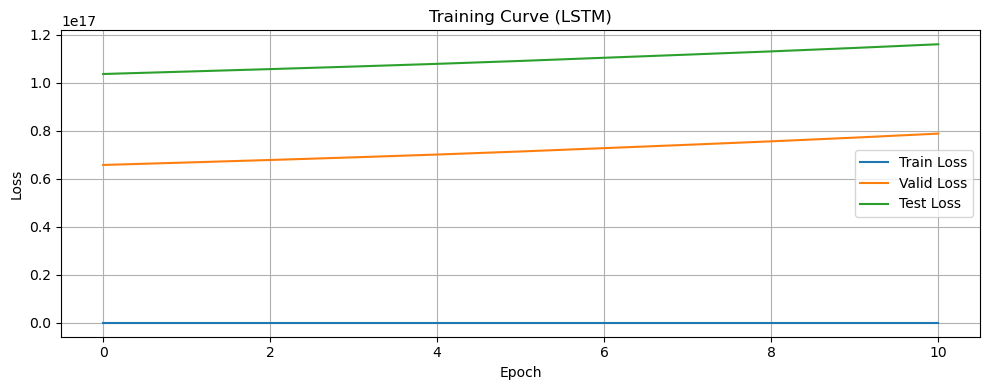

Seed set to 2026
Seed set to 2026


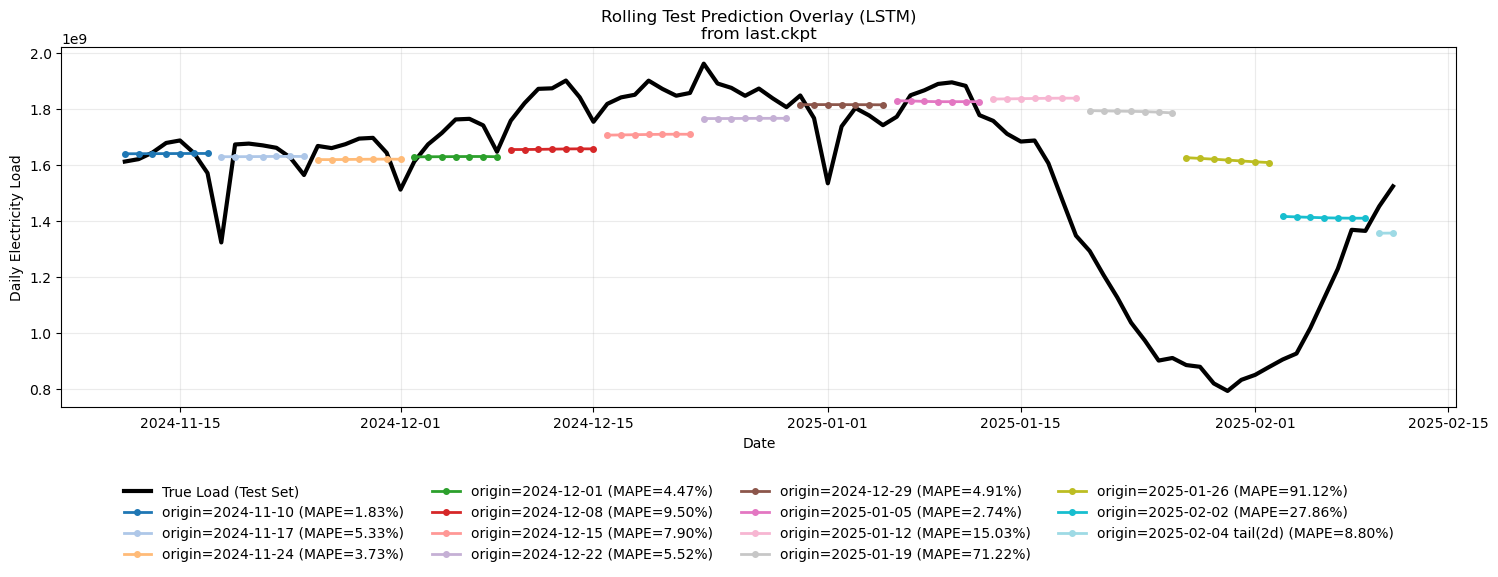

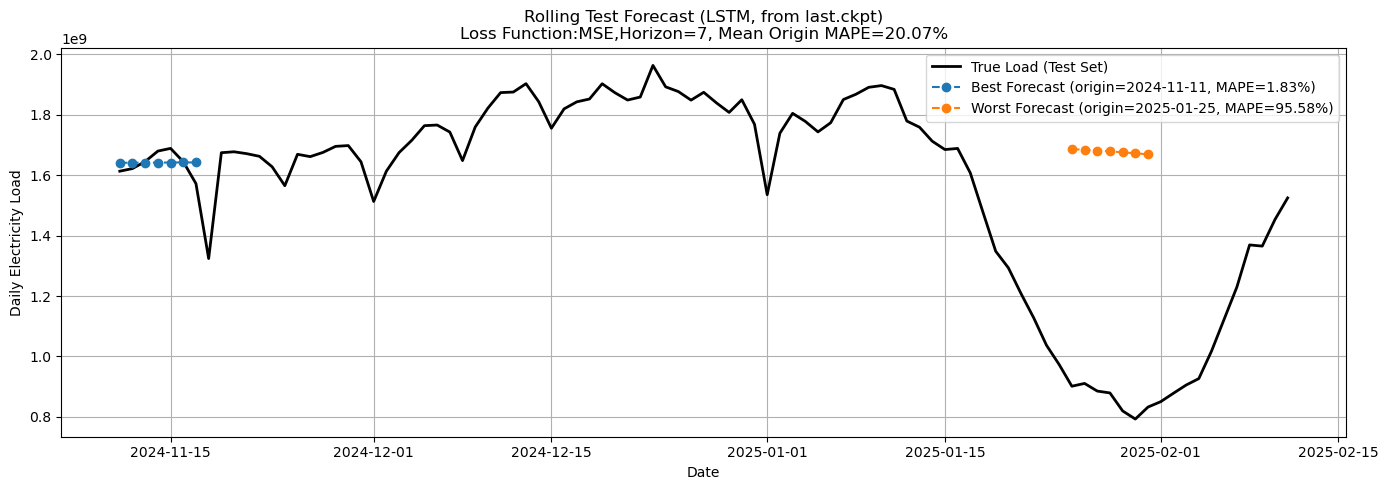

{'model_name': 'LSTM', 'val_overall_mape': 11.025295116875299, 'overall_mape': 20.065937231107235, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\LSTM_no_feat\\20260418_192729', 'best_model_path': 'artifacts\\LSTM_no_feat\\20260418_192729\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\LSTM_no_feat\\20260418_192729\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\LSTM_no_feat\\20260418_192729\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\LSTM_no_feat\\20260418_192729\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\LSTM_no_feat\20260418_192729\rolling_test_raw.csv


In [3]:
from neuralforecast.models import LSTM

lstm_spec = ModelSpec(
    name='LSTM',
    model_type='neural',
    model_cls=LSTM,
    model_params={
        'encoder_hidden_size': 64,
        'encoder_n_layers': 2,
        'encoder_dropout': 0.1,
        'decoder_hidden_size': 64,
        'decoder_layers': 2,
        'max_epochs': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

lstm_result = runner.run(lstm_spec)
print(lstm_result.summary())
print(f"rolling_raw_path: {lstm_result.rolling_raw_path}")


Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026


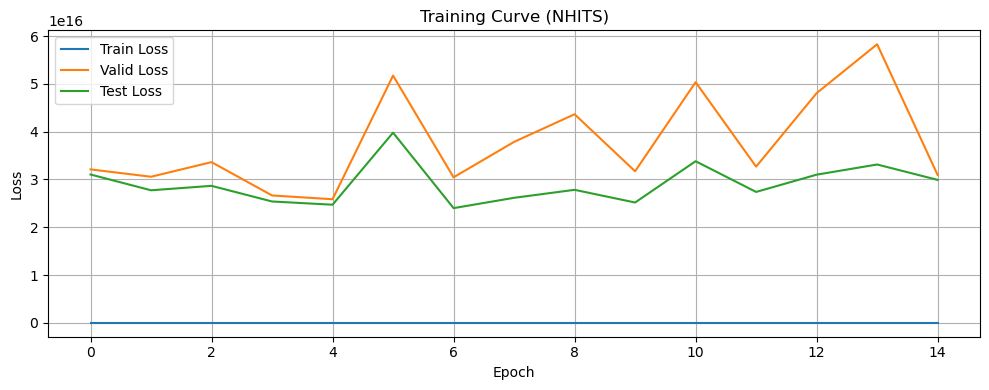

Seed set to 2026
Seed set to 2026


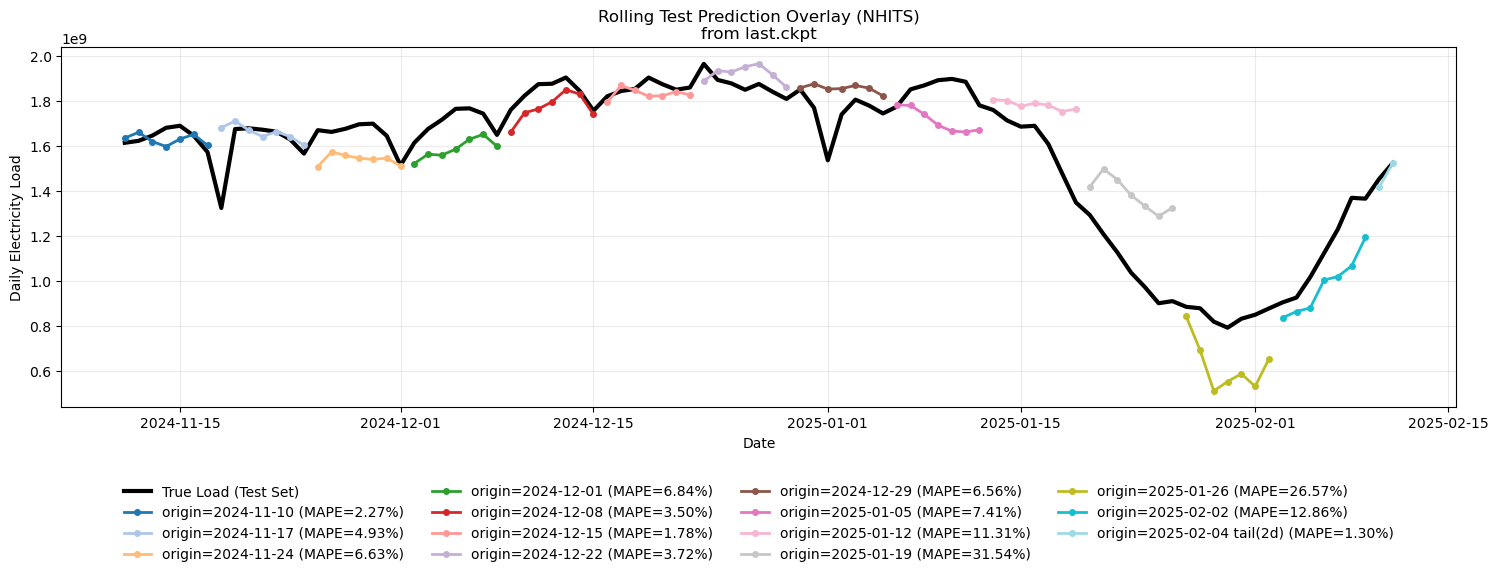

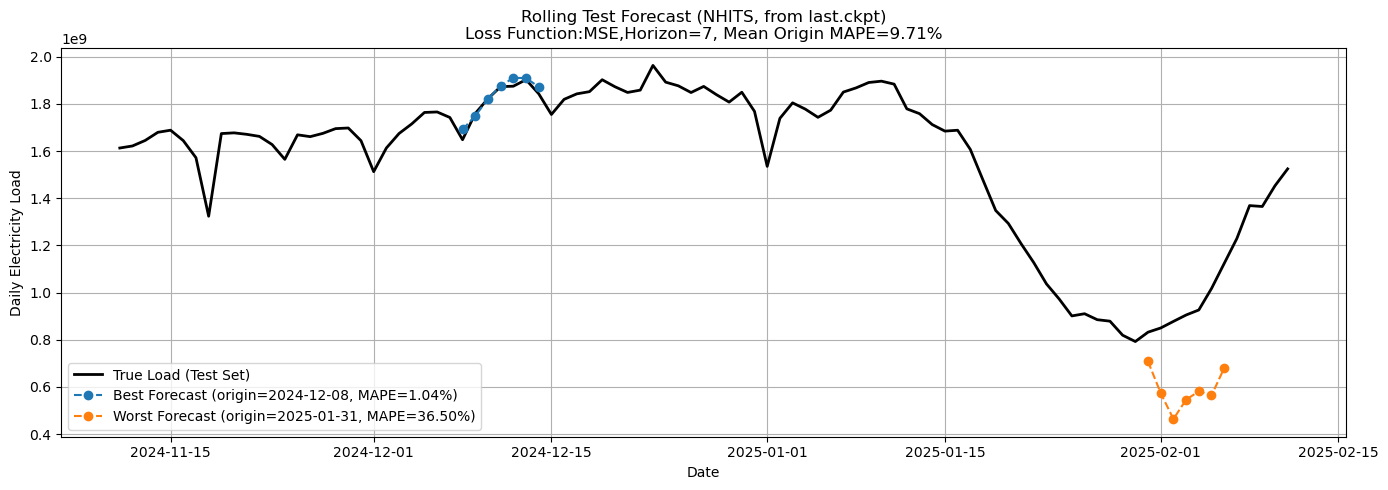

{'model_name': 'NHITS', 'val_overall_mape': 7.419665857485289, 'overall_mape': 9.707423221154226, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\NHITS_no_feat\\20260418_193004', 'best_model_path': 'artifacts\\NHITS_no_feat\\20260418_193004\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\NHITS_no_feat\\20260418_193004\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\NHITS_no_feat\\20260418_193004\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\NHITS_no_feat\\20260418_193004\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\NHITS_no_feat\20260418_193004\rolling_test_raw.csv


In [4]:
from neuralforecast.models import NHITS

nhits_spec = ModelSpec(
    name='NHITS',
    model_type='neural',
    model_cls=NHITS,
    model_params={
        'max_epochs': 100,
        'learning_rate': 1e-3,
        'scaler_type': 'standard',
    },
    supports_future_exog=True,
)

nhits_result = runner.run(nhits_spec)
print(nhits_result.summary())
print(f"rolling_raw_path: {nhits_result.rolling_raw_path}")


Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026
Seed set to 2026


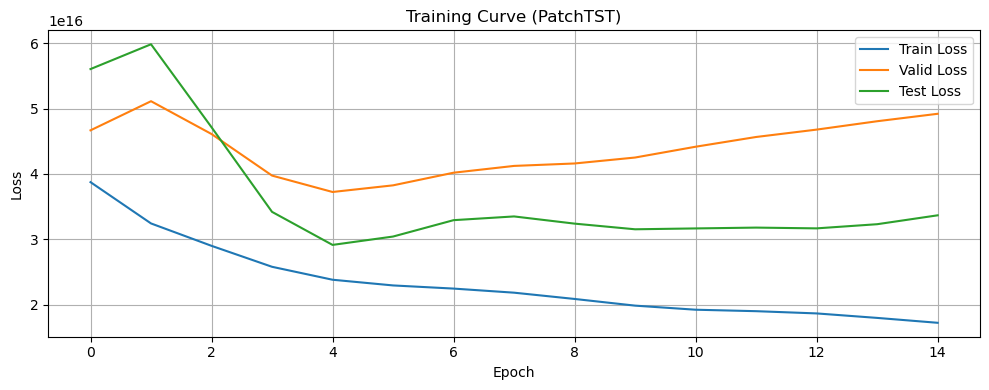

Seed set to 2026
Seed set to 2026


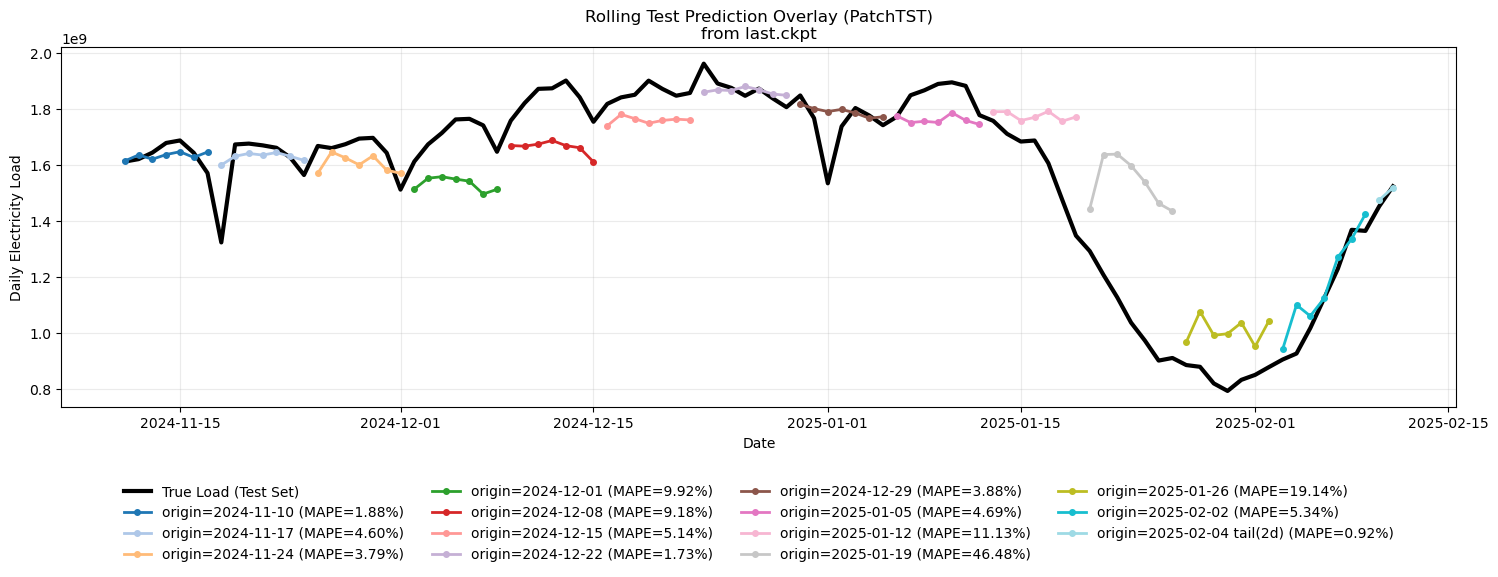

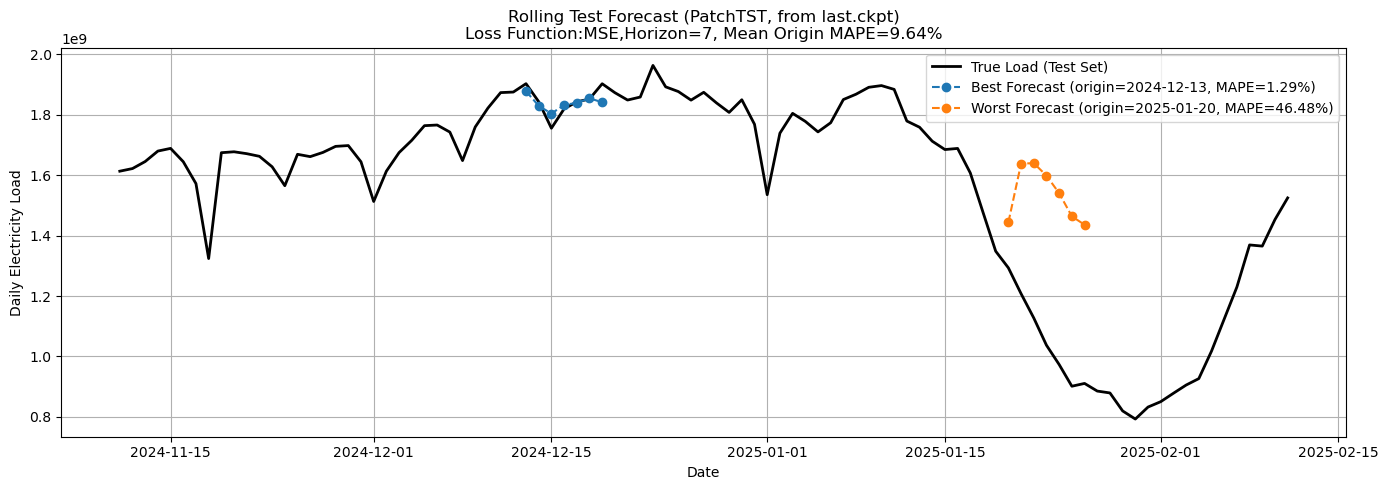

{'model_name': 'PatchTST', 'val_overall_mape': 8.682953840943737, 'overall_mape': 9.639197740625963, 'skipped': False, 'skip_reason': None, 'artifact_dir': 'artifacts\\PatchTST_no_feat\\20260418_193528', 'best_model_path': 'artifacts\\PatchTST_no_feat\\20260418_193528\\checkpoints\\last.ckpt', 'val_best_model_path': 'artifacts\\PatchTST_no_feat\\20260418_193528\\checkpoints\\val_best.ckpt', 'test_best_model_path': None, 'rolling_raw_path': 'artifacts\\PatchTST_no_feat\\20260418_193528\\rolling_test_raw.csv', 'overlay_plot_path': 'artifacts\\PatchTST_no_feat\\20260418_193528\\rolling_test_overlay.png'}
rolling_raw_path: artifacts\PatchTST_no_feat\20260418_193528\rolling_test_raw.csv


In [5]:
from neuralforecast.models import PatchTST

# PatchTST does not support historical or future exogenous variables in this repo.
# If USE_HIST_EXOG=True or USE_FUTR_EXOG=True, rerun the setup cell with both set to False before training PatchTST.
patchtst_spec = ModelSpec(
    name='PatchTST',
    model_type='neural',
    model_cls=PatchTST,
    model_params={
        'n_heads': 4,
        'hidden_size': 128,
        'dropout': 0.1,
        'max_epochs': 100,
        'learning_rate': 1e-3,
    },
    supports_hist_exog=False,
    supports_future_exog=False,
)

patchtst_result = runner.run(patchtst_spec)
print(patchtst_result.summary())
print(f"rolling_raw_path: {patchtst_result.rolling_raw_path}")


In [6]:
# from lightgbm import LGBMRegressor

# lgbm_spec = ModelSpec(
#     name='LGBMRegressor',
#     model_type='ml',
#     model_cls=LGBMRegressor,
#     model_params={
#         'n_estimators': 200,
#         'random_state': RANDOM_SEED,
#     },
#     supports_future_exog=True,
# )

# lgbm_result = runner.run(lgbm_spec)
# print(lgbm_result.summary())
# print(f"rolling_raw_path: {lgbm_result.rolling_raw_path}")


In [7]:
# from statsforecast.models import Naive

# naive_spec = ModelSpec(
#     name='Naive',
#     model_type='stats',
#     model_cls=Naive,
#     model_params={},
# )

# naive_result = runner.run(naive_spec)
# print(naive_result.summary())
# print(f"rolling_raw_path: {naive_result.rolling_raw_path}")


In [8]:
# from neuralforecast.models import TimeLLM

# # TimeLLM requires `transformers`.
# # It does not support historical or future exogenous variables in this repo.
# # If USE_HIST_EXOG=True or USE_FUTR_EXOG=True, rerun the setup cell with both set to False before training TimeLLM.
# timellm_spec = ModelSpec(
#     name='TimeLLM',
#     model_type='neural',
#     model_cls=TimeLLM,
#     model_params={
#         'llm': 'openai-community/gpt2',
#         'max_epochs': 5,
#         'learning_rate': 1e-4,
#         'batch_size': 1,
#         'scaler_type': 'identity',
#         'prompt_prefix': 'Forecast the next daily electricity load values.',
#     },
#     supports_hist_exog=False,
#     supports_future_exog=False,
# )

# timellm_result = runner.run(timellm_spec)
# print(timellm_result.summary())
# print(f"rolling_raw_path: {timellm_result.rolling_raw_path}")
